## House Price Prediction - Exploratory Data Analysis

### Problem Statement
- Predict house prices based on housing features such as area, number of bedrooms,
bathrooms, and location. 

### Dataset
- Dataset Source - https://www.kaggle.com/datasets/nishanpokh/house-price-dataset-nepal

### Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Load the dataset

In [2]:
df=pd.read_csv("../data/raw/Nepali_house_dataset.csv")

### Dataset information
- Title ------------------------------>Tile of post
- Location---------------------------->Address of property
- Price------------------------------->Price in NRs.
- Land Area--------------------------->Area of the land (Anna, sq feet)
- Build Area-------------------------->Area occupied by house (sq feet)
- Road Access------------------------->Road width
- Facing------------------------------>Direction of the property
- Floor------------------------------->No of floor
- Bedroom ---------------------------->No of bedrooms
- Bathroom---------------------------->No of bathrooms
- Build Year-------------------------->Year of construction (Not available for some houses)
- Parking----------------------------->No of parking space
- Amenities--------------------------->Additional facilities

### Show top 5 records

In [3]:
df.head()

,TITLE,LOCATION,PRICE,LAND AREA,BUILDUP AREA,ROAD ACCESS,FACING,FLOOR,BEDROOM,BATHROOM,BUILT YEAR,PARKING,AMENITIES
0,House for Sale,"Imadol, Lalitpur",Rs. 2.9 Cr,4.0 aana,NaN,12 Feet,West,3.0,5.0,4.0,2076 B.S,1 CaRs. & 2 Bikes,"['Earthquake Resistant', 'Marbel', 'Parquet', ..."
1,House for Sale,"Satdobato, Lalitpur",Rs. 4.75 Cr,3.0 aana,NaN,10 Feet,West,4.5,5.0,6.0,2076 B.S,2 CaRs. & 2 Bikes,"['Earthquake Resistant', 'Parquet', 'Drinking ..."
2,4 BHK House for Sale,"Imadol, Lalitpur",Rs. 1.99 Cr,2.3 aana,NaN,10 Feet,West,2.5,4.0,4.0,2060 B.S,1 CaRs. & 3 Bikes,"['Earthquake Resistant', 'Marbel', 'Parquet', ..."
3,Bungalow House for Sale,"Bhaisepati, Lalitpur",Rs. 4 Cr,7.0 aana,NaN,12 Feet,North-West,2.5,4.0,3.0,2059 B.S,4 CaRs. & 4 Bikes,"['Earthquake Resistant', 'Marbel', 'Parquet', ..."
4,House for Rent,"Maharajgunj, Kathmandu",Rs. 12000000,6.0 aana,NaN,20 Feet,South,2.0,4.0,4.0,2071 B.S,4 CaRs. & 5 Bikes,"['Earthquake Resistant', 'Parquet', 'Parking',..."


Column 'TITLE' can be dropped because it contains no useful information for prediction.

#### Shape of the dataset

In [4]:
df.shape

(3418, 13)

### Checking Missing Values

In [5]:
df.isna().sum()

TITLE              0
LOCATION           0
PRICE              0
LAND AREA         89
BUILDUP AREA    2699
ROAD ACCESS        9
FACING           206
FLOOR             95
BEDROOM          282
BATHROOM         346
BUILT YEAR        61
PARKING         2786
AMENITIES          0
dtype: int64

### Checking Data types

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3418 entries, 0 to 3417
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TITLE         3418 non-null   object 
 1   LOCATION      3418 non-null   object 
 2   PRICE         3418 non-null   object 
 3   LAND AREA     3329 non-null   object 
 4   BUILDUP AREA  719 non-null    object 
 5   ROAD ACCESS   3409 non-null   object 
 6   FACING        3212 non-null   object 
 7   FLOOR         3323 non-null   float64
 8   BEDROOM       3136 non-null   float64
 9   BATHROOM      3072 non-null   float64
 10  BUILT YEAR    3357 non-null   object 
 11  PARKING       632 non-null    object 
 12  AMENITIES     3418 non-null   object 
dtypes: float64(3), object(10)
memory usage: 347.3+ KB


#### Observations:
- 89 rows are missing in land area. Land area is important. So, it can be filled with median as median is better than mean for real estate.
- 2699 out of 3418 rows in  buildup area is null. So, it can be dropped.
- Road access has only 9 missing values. So, it can be filled  with median.
- Facing has 177 missing values. It can be filled with mode.
- Floor, bedroom, bathroom and built year can be filled with median as they have small missing number and are important.
- Parking has only 632 non-null values out of 3418. So, it can also be dropped.


### Exploring Data

In [7]:
df["PRICE"].unique()

array(['Rs. 2.9 Cr ', 'Rs. 4.75 Cr ', 'Rs. 1.99 Cr ', 'Rs. 4 Cr ',
       'Rs. 12000000', 'Rs. 27000000', 'Rs. 3.3 Cr ', 'Rs. 4.5 Cr ',
       'Rs. 3 Cr', 'Rs. 4.99 Cr ', 'Rs. 2.45 Cr ', 'Rs. 2.5 Cr ',
       'Rs. 4.25 Cr ', 'Rs. 6.5 Cr ', 'Rs. 3.6 Cr ', 'Rs. 5.8 Cr ',
       'Rs. 4.8 Cr ', 'Rs. 6.65 Cr ', 'Rs. 13.3 Cr ', 'Rs. 8.5 Cr ',
       'Rs. 5.5 Cr ', 'Rs. 2.95 Cr ', 'Rs. 6.35 Cr ', 'Rs. 10.5 Cr ',
       'Rs. 6.4 Cr ', 'Rs. 3.5 Cr ', 'Rs. 2.2 Cr ', 'Rs. 3.75 Cr ',
       'Rs. 8 Cr ', 'Rs. 7.75 Cr ', 'Rs. 16 Cr ', 'Rs. 3.19 Cr ',
       'Rs. 12 Cr ', 'Rs. 6.25 Cr ', 'Rs. 2.8 Cr ', 'Rs. 5.99 Cr ',
       'Rs. 3.35 Cr ', 'Rs. 3.50 Cr', 'Rs. 6 Cr ', 'Rs. 2.7 Cr ',
       'Rs. 2.75 Cr ', 'Rs. 11 Cr ', 'Rs. 3.25 Cr ', 'Rs. 3.1 Cr ',
       'Rs. 4 Cr', 'Rs. 3.15 Cr ', 'Rs. 4.65 Cr ', 'Rs. 5.95 Cr ',
       'Rs. 3.9 Cr ', 'Rs. 3.2 Cr ', 'Rs. 5.15 Cr ', 'Rs. 2.3 Cr ',
       'Rs. 1.7 Cr ', 'Rs. 2.4 Cr ', 'Rs. 2.25 Cr ', 'Rs. 1.8 Cr ',
       'Rs. 1.65 Cr ', 'Rs. 5.1 Cr ', 'Rs. 50 Lac/aa

In [8]:
unit_prices = df["PRICE"][df["PRICE"].str.contains("/", na=False)]
print(f"Total unit prices: {len(unit_prices)}")
print("\nSample unit prices:")
print(unit_prices.head(20))

lac_per_m = unit_prices.str.contains("/m", case=False, na=False).sum()
lac_per_anna = unit_prices.str.contains("/aana", case=False, na=False).sum()

print(f"\nLac/m: {lac_per_m}")
print(f"Lac/anna: {lac_per_anna}")

Total unit prices: 561

Sample unit prices:
84     Rs. 50 Lac/aana
98       Rs. 65,000 /m
109      Rs. 1.4 Lac/m
111      Rs. 1.5 Lac/m
127     Rs. 1.05 Lac/m
136    Rs. 90 Lac/aana
159      Rs. 2.5 Lac/m
163    Rs. 70 Lac/aana
166    Rs. 21 Lac/aana
168      Rs. 60,000 /m
169      Rs. 3.5 Lac/m
171      Rs. 80,000 /m
172      Rs. 70,000 /m
173      Rs. 45,000 /m
197      Rs. 80,000 /m
199      Rs. 1.5 Lac/m
201      Rs. 1.6 Lac/m
202     Rs. 1.28 Lac/m
211      Rs. 1.4 Lac/m
216      Rs. 90,000 /m
Name: PRICE, dtype: object

Lac/m: 534
Lac/anna: 26


#### Observations on Price Cleaning:
- **Total unit prices found: 561** (about 16% of dataset)
  - Lac/m (price per square meter): 534 entries
  - Lac/anna (price per anna): 26 entries
- **Reason for filtering unit prices:** These represent price per unit area, not total property price. They are fundamentally different from total prices and not directly comparable for prediction modeling.
- **Buildup area not viable:** Buildup area column has 79% missing values, making it unreliable for converting unit prices back to total prices.
- **Strategy applied:** Unit prices and "Price on call" entries are converted to `NaN` to be handled by missing value imputation later.
- **Price conversion handled:** 
  - "Cr" (Crore) multiplied by 10,000,000
  - "Lakh" and "Lac" (both spellings) multiplied by 100,000
  - Commas removed from numbers before parsing
  - Case-insensitive matching for currency indicators

In [9]:
df["LAND AREA"].unique()

array(['4.0 aana', '3.0 aana', '2.3 aana', '7.0 aana', '6.0 aana',
       '3.2 aana', '4.3 aana', '2.2 aana', '5.0 aana', '5.2 aana',
       '6.2 aana', '4.2 aana', '4.1 aana', '9.6 aana', '3.1 aana',
       '11.0 aana', '3.3 aana', '9.0 aana', '12 aana', '6.4 aana',
       '12.0 aana', '3.5 aana', '6 aana', '7.1 aana', '6.3 aana',
       '15.0 aana', '12.1 aana', '16.0 aana', '9.3 aana', '9.1 aana',
       '5.1 aana', '28.0 aana', '0.14 kattha', '24.0 aana', '14.4.0 aana',
       '13.2 aana', '32.0 aana', '0.0 aana', '6.1 aana', '2.9 aana',
       '7.2 aana', '8.0 aana', '10.2 aana', '35.0 aana', '37.0 aana',
       '10.0 aana', '127 sq. mtr', '22.0 aana', '30.0 aana', '18.0 aana',
       '23.0 aana', '7.3 aana', '14.0 aana', '13.0 aana', '1.0 aana',
       '5.3 aana', nan, '40.0 aana', '2.5 aana', '0.12 kattha',
       '21.0 aana', '0.5 kattha', '1.2 aana', '8.2 aana', '20.0 aana',
       '1.1 aana', '3.8 aana', '1.9.9 kattha', '0.11 kattha', '9.2 aana',
       '2700 sq. ft', '48.0 a

LAND_AREA values are in multiple units:
- aana (most common)
- kattha
- sq. ft (square feet)
- sq. mtr (square meters)

This breaks regression because:
- 4.0 aana ≠ 4.0 sq. ft (completely different scales)
- Without conversion, the model would treat "4 aana" and "4 sq. ft" as equivalent when they're not.
- This introduces massive noise and bias into the model.
Conversion factors:
- 1 aana ≈ 31.36 sq. ft
- 1 kattha = 4 aana ≈ 125.44 sq. ft
- 1 sq. mtr ≈ 10.764 sq. ft

So, all have to converted to a common unit (sq. ft is practical since most Nepali real estate uses aana):

In [10]:
df["ROAD ACCESS"].unique()

array(['12 Feet', '10 Feet', '20 Feet', '13 Feet', '14 Feet', '16 Feet',
       '26 Feet', '25 Feet', '19 Feet', '18 Feet', '15 Feet', '24 Feet',
       '27 Feet', '30 Feet', '9 Meter', '22 Feet', '23 Feet', '8 Feet',
       '11 Feet', '20 Meter', nan, '35 Feet', '6 Feet', '10 Meter',
       '4 Feet', '40 Feet', '17 Feet', '13 Meter', '13-20 Feet',
       '10-12 Feet', '12-18 Feet', '28 Feet', '10-15 Feet', '12-16 Feet',
       '32 Feet', '12/20 Feet', '9 Feet', '12-14 Feet', '22  Feet',
       '15-26 Feet', '14-20 Feet', '15-20 Feet', '5 Feet', '10-20 Feet',
       '12-13 Feet', '10-16 Feet', '14-26 Feet', '8-10 Feet',
       '12/13 Feet', '20  Feet', '9-12 Feet', '13  Feet', '10/13 Feet',
       '10-24 Feet', '16-22 Feet', '20-26 Feet', '13-15 Feet',
       '13-16 Feet', '12-15 Feet', '8-12 Feet', '15-24 Feet',
       '13-24 Feet', '10-26 Feet', '36 Feet', '12-20 Feet', '10-14 Feet',
       '12-26 Feet', '13-18 Feet', '15 Meter', '21 Feet', '0 Feet',
       '16-20 Feet', '10-18 Feet'

Only number should be extracted from road access and mean should be taken in case of range.

In [11]:
df["FACING"].unique()

array(['West', 'North-West', 'South', 'South-East', 'North-East', 'East',
       'South-West', 'North', nan, 'South East', 'South West', 'south',
       'North East', 'North West', 'west', 'EAST', 'West-South', 'WEST',
       'North- East', 'south west', 'NORTH', 'South-EAST', 'SOUTH',
       'East/South', 'NORTH-WEST', 'SOUTH-EAST', 'EAST-SOUTH',
       'SOUTH-WEST', 'WEST / NORTH', 'EAST-NORTH', 'EAST/WEST',
       'East-North', 'NORTH/EAST', 'South-east', 'East-South',
       'WEST-NORTH', 'WEST-SOUTH'], dtype=object)

Facing contains many duplicates. So, the text should be normalized by converting everything to lowercase and mapping can be used to reduce categories.

In [12]:
df["BUILT YEAR"].unique()

array(['2076 B.S', '2060 B.S', '2059 B.S', '2071 B.S', '2074 B.S',
       '2065 B.S', '2066 B.S', '2075 B.S', '2079 B.S', '2070 B.S',
       '2078 B.S', '2077 B.S', '2080 B.S', '2068 B.S', '2073 B.S',
       '2072 B.S', '2063 B.S', '2058 B.S', '2064 B.S', '2069 B.S',
       '2055 B.S', '2061 B.S', '2050 B.S', nan, '2062 B.S', '2049 B.S',
       '2047 B.S', '2052 B.S', '2054 B.S', '2056 B.S', '2067 B.S',
       '2057 B.S', '#NAME? B.S', '2045 B.S', '2060', '2065', '2073',
       '2075', '2071', '2048 B.S'], dtype=object)

Only number should be extracted from built year by removing "B.S.".

In [13]:
df["AMENITIES"].unique()

array(["['Earthquake Resistant', 'Marbel', 'Parquet', 'Parking', 'Drinking Water', 'Terrace', 'Modular Kitchen', 'Closet', 'Dining Room', 'Pantry', 'Bed Room']",
       "['Earthquake Resistant', 'Parquet', 'Drinking Water', 'Parking', 'Modular Kitchen', 'Closet', 'Bed Room', 'Pantry', 'Dining Room', 'Bathroom', 'Store Room']",
       "['Earthquake Resistant', 'Marbel', 'Parquet', 'Parking', 'Drinking Water', 'Balcony', 'Closet', 'Modular Kitchen', 'MiCrowave', 'Bed Room', 'Dining Room']",
       ..., "['Garage']", "['Garage', 'Parking']",
       "['Lawn', 'Garage', 'Air Condition', 'Backyard', 'Balcony', 'Microwave', 'Gym', 'Garden', 'Frontyard', 'Fencing', 'Deck', 'Modular Kitchen', 'TV Cable', 'Washing Machine', 'Wifi', 'Drainage', 'CCTV', 'Water Tank', 'Water Well', 'Power Backup Water', 'Water Supply', 'Power Backup', 'Internet', 'Kids Playground']"],
      shape=(1713,), dtype=object)

Amenities column contains list-like strings with multiple items per property. So,it can be converted into a numeric column representing how many amenities each property has and also top 10 amenities can be one hot encode to form 10 columns.

### Feature Engineering

The bathroom-per-bedroom ratio can be a useful feature in real estate regression models because it reflects layout efficiency and buyer expectations. A ratio near 1:1 is often desirable, while very high ratios may offer diminishing returns and add maintenance overhead.

Models understand age better than raw year

Area × Road Access can be added as Large land + wide road → very high value.

Area x Bedroom interaction can also be added.

### Checking Duplicates

In [14]:
df.duplicated().sum()

np.int64(0)

Removing the Duplicates

In [15]:
df = df.drop_duplicates()

### Correlation Analysis

In [ ]:
df = pd.read_csv("../data/processed/clean_housing.csv")

<Axes: >

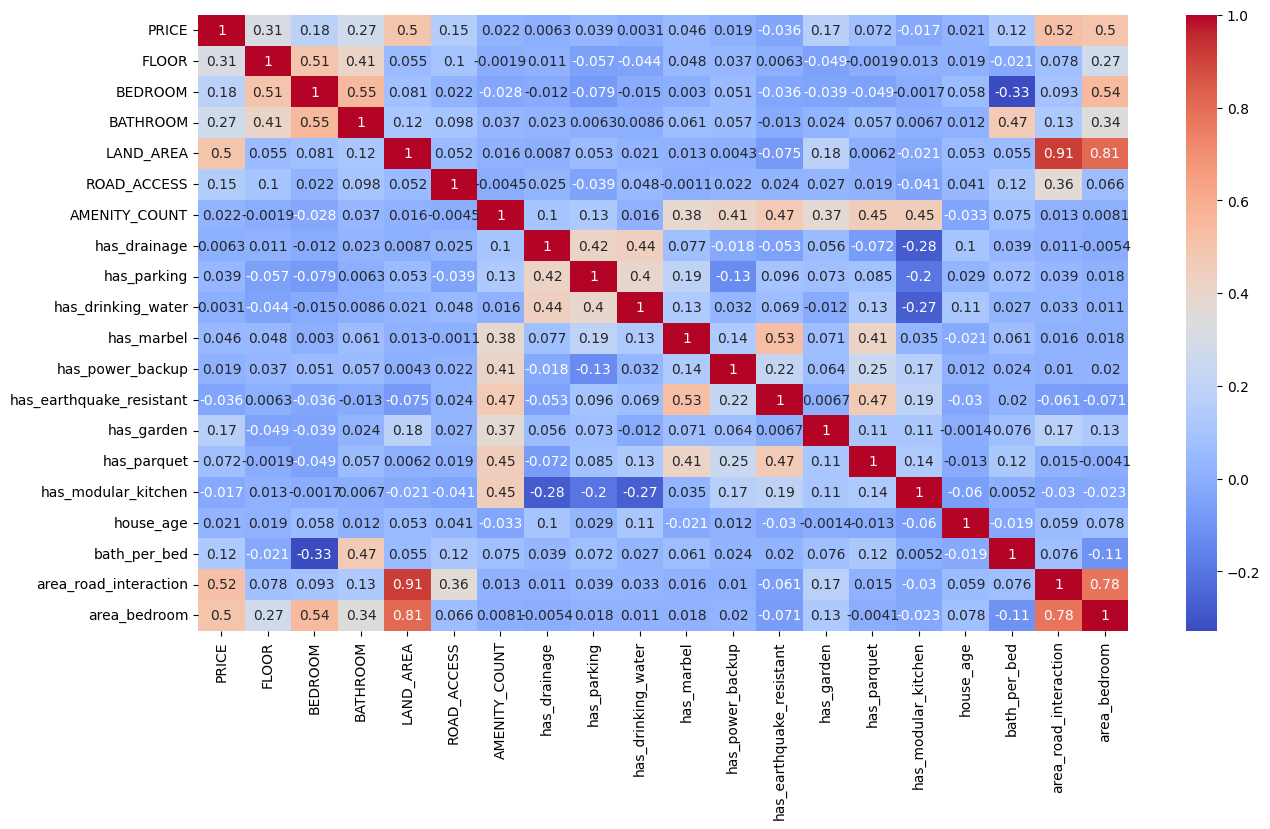

In [4]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(15,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

In [5]:
corr

,PRICE,FLOOR,BEDROOM,BATHROOM,LAND_AREA,ROAD_ACCESS,AMENITY_COUNT,has_drainage,has_parking,has_drinking_water,has_marbel,has_power_backup,has_earthquake_resistant,has_garden,has_parquet,has_modular_kitchen,house_age,bath_per_bed,area_road_interaction,area_bedroom
PRICE,1.000000,0.311357,0.184494,0.271626,0.500296,0.151849,0.021820,0.006279,0.038646,0.003089,0.045548,0.018887,-0.036464,0.165538,0.071744,-0.017164,0.020500,0.123875,0.518880,0.504434
FLOOR,0.311357,1.000000,0.506018,0.412520,0.055460,0.100293,-0.001866,0.010864,-0.056865,-0.043969,0.047717,0.037113,0.006302,-0.049021,-0.001887,0.012691,0.018807,-0.020730,0.078372,0.271012
BEDROOM,0.184494,0.506018,1.000000,0.549075,0.081337,0.021563,-0.027821,-0.011781,-0.078943,-0.014880,0.003039,0.050585,-0.036244,-0.038795,-0.048913,-0.001655,0.058499,-0.328201,0.092554,0.543783
BATHROOM,0.271626,0.412520,0.549075,1.000000,0.117386,0.098491,0.036964,0.022756,0.006264,0.008557,0.061391,0.057226,-0.012939,0.023764,0.057285,0.006734,0.011729,0.474157,0.132969,0.343488
LAND_AREA,0.500296,0.055460,0.081337,0.117386,1.000000,0.052137,0.016198,0.008672,0.053466,0.021354,0.013152,0.004292,-0.075399,0.182529,0.006201,-0.020959,0.053243,0.055145,0.914346,0.809138
ROAD_ACCESS,0.151849,0.100293,0.021563,0.098491,0.052137,1.000000,-0.004481,0.024779,-0.038585,0.048151,-0.001105,0.021606,0.023932,0.026935,0.018860,-0.041309,0.040709,0.115486,0.364323,0.065842
AMENITY_COUNT,0.021820,-0.001866,-0.027821,0.036964,0.016198,-0.004481,1.000000,0.101427,0.126166,0.015653,0.382924,0.411354,0.474144,0.372357,0.452429,0.452054,-0.033147,0.074998,0.012835,0.008078
has_drainage,0.006279,0.010864,-0.011781,0.022756,0.008672,0.024779,0.101427,1.000000,0.416722,0.443488,0.076662,-0.017905,-0.052512,0.055942,-0.072427,-0.280614,0.100124,0.039485,0.011010,-0.005380
has_parking,0.038646,-0.056865,-0.078943,0.006264,0.053466,-0.038585,0.126166,0.416722,1.000000,0.397279,0.194841,-0.126051,0.096177,0.072571,0.085133,-0.201139,0.028654,0.072113,0.038817,0.017746
has_drinking_water,0.003089,-0.043969,-0.014880,0.008557,0.021354,0.048151,0.015653,0.443488,0.397279,1.000000,0.133728,0.032203,0.069147,-0.012366,0.128861,-0.269043,0.107754,0.026527,0.032951,0.011202
